# Predicción de Energía de Adsorción mediante Perceptrón Multicapa (MLP)

Este notebook implementa una red neuronal artificial tipo perceptrón multicapa (MLP) para predecir la energía de adsorción utilizando descriptores del nanotubo.

Se utilizan:

- TensorFlow/Keras
- Scikit-Learn
- Numpy
- Pandas
- Matplotlib

El procedimiento incluye:

1. Cargar datos
2. Preprocesamiento
3. Crear modelo
4. Compilar modelo
5. Entrenar modelo
6. Curva de pérdida (loss)
7. Curva de MAE
8. Predicciones
9. Métricas (R², MAE, MSE, RMSE)
10. Real vs Predicho
11. Tabla de predicciones
12. Guardar modelo

In [17]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

import tensorflow as tf
import random

import matplotlib.pyplot as plt

## Configuración de semillas aleatorias

In [18]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Carga de datos

In [19]:
archivo = "datos_nanotubo.csv"

df = pd.read_csv(archivo)

print("Dimensiones:", df.shape)

df.head()

Dimensiones: (210, 93)


,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,z28,x29,y29,z29,x30,y30,z30,angulo,distancia,energia
0,0.568869,0.508745,0.271539,0.537606,0.549479,0.325686,0.451556,0.512026,0.245746,0.463113,...,0.714212,0.528003,0.496845,0.525244,0.490584,0.496789,0.525386,0.0,0.5,12.864541
1,0.568869,0.508745,0.271539,0.537606,0.549479,0.325686,0.451556,0.512026,0.245746,0.463113,...,0.714212,0.528017,0.496995,0.552397,0.490598,0.496938,0.552523,0.0,1.0,12.733951
2,0.568869,0.508745,0.271539,0.537606,0.549479,0.325686,0.451556,0.512026,0.245746,0.463113,...,0.714212,0.528148,0.497042,0.576349,0.490729,0.496986,0.576476,0.0,1.5,11.740177
3,0.568869,0.508745,0.271539,0.537606,0.549479,0.325686,0.451556,0.512026,0.245746,0.463113,...,0.714212,0.528139,0.497112,0.600534,0.490720,0.497055,0.600661,0.0,2.0,11.419885
4,0.568869,0.508745,0.271539,0.537606,0.549479,0.325686,0.451556,0.512026,0.245746,0.463113,...,0.714212,0.528308,0.497057,0.627137,0.490889,0.497001,0.627264,0.0,2.5,11.174502


## Separación de variables

In [20]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print("X =", X.shape)
print("y =", y.shape)

X = (210, 92)
y = (210,)


## División de conjuntos

In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Entrenamiento:", X_train.shape)
print("Validación:", X_val.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (168, 92)
Validación: (21, 92)
Prueba: (21, 92)


## Normalización de datos

In [22]:
scaler_X = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)

scaler_y = StandardScaler()

y_train = scaler_y.fit_transform(
    y_train.reshape(-1,1)
)

y_val = scaler_y.transform(
    y_val.reshape(-1,1)
)

y_test_scaled = scaler_y.transform(
    y_test.reshape(-1,1)
)

## Construcción del modelo MLP

In [23]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(0.2))

model.add(Dense(
    64,
    activation='relu'
))

model.add(Dropout(0.2))

model.add(Dense(
    32,
    activation='relu'
))

model.add(Dense(
    1,
    activation='linear'
))

In [24]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        11,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,273 (87.00 KB)

 Trainable params: 22,273 (87.00 KB)

 Non-trainable params: 0 (0.00 B)

## Configuración de entrenamiento

In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

## Entrenamiento del modelo

In [26]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=1000,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 1.0982 - mae: 0.9994 - val_loss: 0.6680 - val_mae: 0.7664 - learning_rate: 0.0010
Epoch 2/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8218 - mae: 0.8658 - val_loss: 0.5569 - val_mae: 0.6993 - learning_rate: 0.0010
Epoch 3/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7008 - mae: 0.7899 - val_loss: 0.4591 - val_mae: 0.6319 - learning_rate: 0.0010
Epoch 4/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5841 - mae: 0.6921 - val_loss: 0.3715 - val_mae: 0.5537 - learning_rate: 0.0010
Epoch 5/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4710 - mae: 0.5937 - val_loss: 0.2993 - val_mae: 0.4629 - learning_rate: 0.0010
Epoch 6/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4291 - mae: 0.5232 - val_loss: 0.2526 - val_mae: 0.3842 - learning_rate: 0.0010
Epoch 7/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4119 - mae: 0.5056 - val_loss: 0.2267 - val_mae: 0.3533 - learning_rate: 0.0010
Epoch 8/1000


## Evolución de la función de pérdida

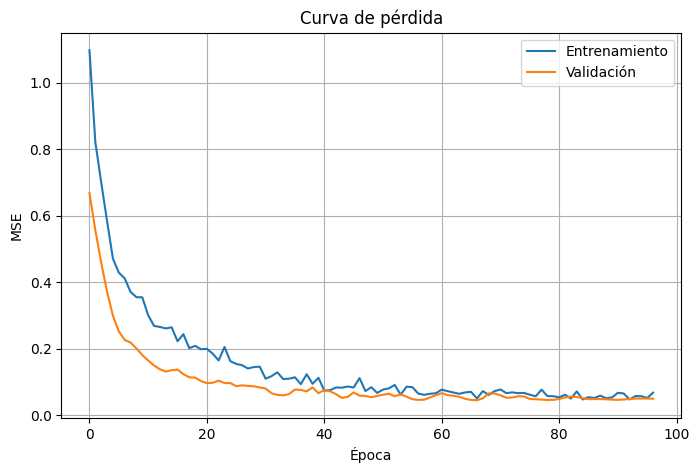

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Entrenamiento'
)

plt.plot(
    history.history['val_loss'],
    label='Validación'
)

plt.xlabel('Época')
plt.ylabel('MSE')
plt.title('Curva de pérdida')
plt.legend()
plt.grid(True)

plt.savefig(
    "curva_perdida.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Curva de MAE de entrenamiento y validación

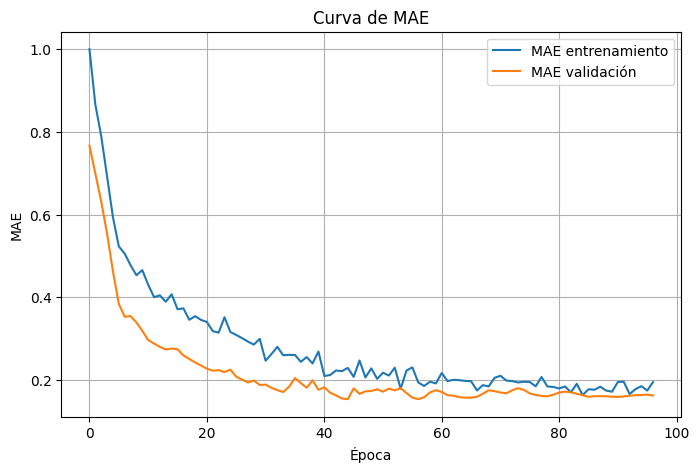

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['mae'],
    label='MAE entrenamiento'
)

plt.plot(
    history.history['val_mae'],
    label='MAE validación'
)

plt.xlabel('Época')
plt.ylabel('MAE')
plt.title('Curva de MAE')
plt.legend()
plt.grid(True)

plt.savefig(
    "curva_mae.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Predicción sobre el conjunto de prueba

In [29]:
# Predicciones

y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(
    y_pred_scaled
)

# Tabla de resultados

tabla_resultados = pd.DataFrame({
    'Real': y_test,
    'Predicción': y_pred.flatten()
})

tabla_resultados['Error absoluto'] = (
    abs(
        tabla_resultados['Real']
        - tabla_resultados['Predicción']
    )
)

tabla_resultados.head(10)

# Mejores
tabla_resultados.sort_values(
    by='Error absoluto'
).head(10)

# Peores
tabla_resultados.sort_values(
    by='Error absoluto',
    ascending=False
).head(10)


tabla_resultados.to_csv(
    "predicciones_modelo.csv",
    index=False
)

print("Tabla guardada.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Tabla guardada.


## Métricas de desempeño

In [30]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("RESULTADOS")
print("----------------------")
print(f"R²   = {r2:.4f}")
print(f"MAE  = {mae:.4f}")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")

RESULTADOS
----------------------
R²   = 0.9767
MAE  = 0.6144
MSE  = 0.5492
RMSE = 0.7411


## Comparación entre valores reales y predichos

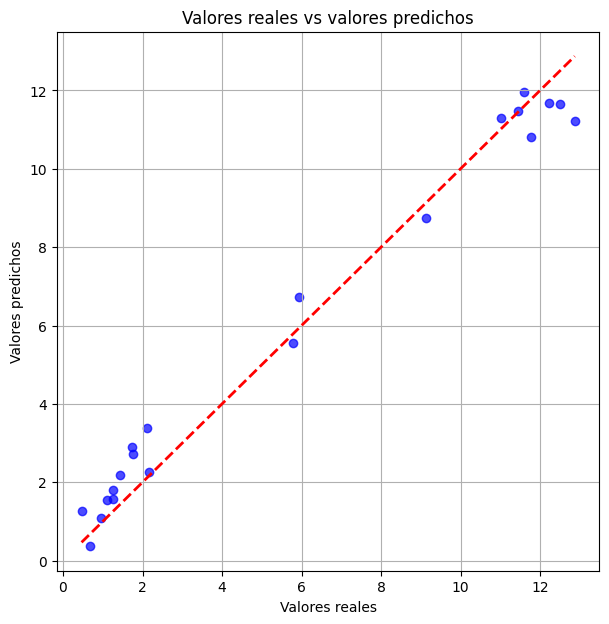

In [31]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7,
    color='blue'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Valores reales vs valores predichos')

plt.grid(True)

plt.savefig(
    "real_vs_predicho.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Guardado del modelo entrenado

In [32]:
model.save(
    "modelo_nanotubo.keras"
)

print("Modelo guardado correctamente.")


Modelo guardado correctamente.


## Resumen de resultados

El modelo MLP fue evaluado mediante las métricas:

- Coeficiente de determinación (R²)
- Error absoluto medio (MAE)
- Error cuadrático medio (MSE)
- Raíz del error cuadrático medio (RMSE)

Además se presentan:

- Curva de pérdida de entrenamiento y validación.
- Curva del MAE de entrenamiento y validación.
- Comparación gráfica entre valores reales y predichos.
- Tabla de ejemplos de predicción con su error absoluto.

Estos resultados permiten evaluar la capacidad predictiva del modelo para estimar la energía de adsorción.